In [2]:
# ============================================================
# Task 4: Anomaly Detection
# ============================================================

# %% Cell 1 — Imports & load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

telemetry_df = pd.read_csv(
    "sensor_telemetry.csv",       
    parse_dates=["timestamp"]
)
asset_df = pd.read_csv("asset_metadata.csv")

print(telemetry_df.shape)
telemetry_df.head()

(178560, 12)


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2026-08-04 21:04:34.276093,SITE-01,SITE-01-BLDG-01,SITE-01-BLDG-01-AST-000,4.34,49.80,102.14,0.411,33.213,0,Idle,0
1,2026-08-04 21:04:34.276093,SITE-02,SITE-02-BLDG-02,SITE-02-BLDG-02-AST-008,23.82,47.99,101.75,0.000,0.000,0,Idle,0
2,2026-08-04 21:04:34.276093,SITE-01,SITE-01-BLDG-01,SITE-01-BLDG-01-AST-009,20.64,40.13,101.95,0.074,0.300,1,Idle,0
3,2026-08-04 21:04:34.276093,SITE-02,SITE-02-BLDG-02,SITE-02-BLDG-02-AST-009,3.80,40.46,101.47,0.378,46.338,1,Idle,0
4,2026-08-04 21:04:34.276093,SITE-02,SITE-02-BLDG-02,SITE-02-BLDG-02-AST-010,27.81,47.06,101.06,0.357,10.457,0,Idle,0


In [3]:
# %% Cell 2 — Handle missing values (same numeric columns EDA/Task 2 would use)
numeric_cols = ["temperature", "humidity", "pressure", "vibration", "power_consumption"]

print("Missing values per column:")
print(telemetry_df[numeric_cols].isna().sum())

# Forward-fill per asset (sensor drop-outs), then fall back to column median for any leading gaps
telemetry_df = telemetry_df.sort_values(["asset_id", "timestamp"])
telemetry_df[numeric_cols] = (
    telemetry_df.groupby("asset_id")[numeric_cols].transform(lambda s: s.ffill().bfill())
)
telemetry_df[numeric_cols] = telemetry_df[numeric_cols].fillna(telemetry_df[numeric_cols].median())

print("\nRemaining missing after fill:", telemetry_df[numeric_cols].isna().sum().sum())

Missing values per column:
temperature          3637
humidity             3551
pressure             3635
vibration            3655
power_consumption    3548
dtype: int64

Remaining missing after fill: 0


In [6]:
# %% Cell 4 (fixed) — Feature engineering for anomaly detection
features_df = telemetry_df.merge(
    asset_df[["asset_id", "asset_type"]], on="asset_id", how="left"
)

# Keep a readable copy of the original categorical values before one-hot encoding
features_df["operating_mode_label"] = features_df["operating_mode"]
features_df["asset_type_label"] = features_df["asset_type"]

# One-hot encode for the model input
features_df = pd.get_dummies(features_df, columns=["asset_type", "operating_mode"], prefix=["type", "mode"])

feature_cols = numeric_cols + [c for c in features_df.columns if c.startswith("type_") or c.startswith("mode_")]

X = features_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numeric_cols])
X_final = np.hstack([X_scaled, X[[c for c in feature_cols if c not in numeric_cols]].values])

print("Feature matrix shape:", X_final.shape)

Feature matrix shape: (178560, 13)


In [7]:
#  Fit Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)

iso_forest.fit(X_final)

features_df["anomaly_score"] = iso_forest.decision_function(X_final)
features_df["is_anomaly"] = iso_forest.predict(X_final)
features_df["is_anomaly"] = (features_df["is_anomaly"] == -1).astype(int)

print(f"Anomalies flagged: {features_df['is_anomaly'].sum()} out of {len(features_df)} "
      f"({features_df['is_anomaly'].mean()*100:.2f}%)")

anomalies_df = features_df[features_df["is_anomaly"] == 1].sort_values("anomaly_score")
anomalies_df[["timestamp", "asset_id", "temperature", "vibration", "power_consumption",
              "operating_mode_label", "anomaly_score", "fault_flag"]].head(15)

Anomalies flagged: 3572 out of 178560 (2.00%)


,timestamp,asset_id,temperature,vibration,power_consumption,operating_mode_label,anomaly_score,fault_flag
85867,2026-08-13 00:39:34.276093,SITE-02-BLDG-01-AST-005,8.65,2.191,74.568,Heating,-0.077434,0
2651,2026-08-14 01:59:34.276093,SITE-01-BLDG-01-AST-000,9.87,2.377,71.927,Heating,-0.076912,0
85335,2026-08-11 04:19:34.276093,SITE-02-BLDG-01-AST-005,11.36,2.057,61.165,Heating,-0.075645,1
86201,2026-08-14 04:29:34.276093,SITE-02-BLDG-01-AST-005,6.39,2.324,4.900,Heating,-0.072089,0
86177,2026-08-14 02:29:34.276093,SITE-02-BLDG-01-AST-005,8.12,2.437,75.399,Heating,-0.070335,0
86010,2026-08-13 12:34:34.276093,SITE-02-BLDG-01-AST-005,8.33,2.208,79.461,Cooling,-0.070292,0
2654,2026-08-14 02:14:34.276093,SITE-01-BLDG-01-AST-000,10.36,2.345,7.605,Heating,-0.070081,0
85914,2026-08-13 04:34:34.276093,SITE-02-BLDG-01-AST-005,9.82,1.920,65.387,Heating,-0.069616,0
86148,2026-08-14 00:04:34.276093,SITE-02-BLDG-01-AST-005,6.22,2.199,69.661,Heating,-0.068841,0
2119,2026-08-12 05:39:34.276093,SITE-01-BLDG-01-AST-000,9.24,1.994,54.420,Heating,-0.068287,0


In [8]:
# %% Cell 6 — Degradation / drift detection: rolling trend features per asset
# Catches slow degradation (rising vibration/temp over time) that a single-point
# Isolation Forest pass can under-weight, since it looks at readings independently.

telemetry_df = telemetry_df.sort_values(["asset_id", "timestamp"])

ROLL_WINDOW = 12  # e.g. last 12 readings (~1 hour at 5-min sampling)

telemetry_df["vibration_roll_mean"] = telemetry_df.groupby("asset_id")["vibration"].transform(
    lambda s: s.rolling(ROLL_WINDOW, min_periods=3).mean()
)
telemetry_df["vibration_roll_slope"] = telemetry_df.groupby("asset_id")["vibration"].transform(
    lambda s: s.diff().rolling(ROLL_WINDOW, min_periods=3).mean()
)
telemetry_df["temperature_roll_slope"] = telemetry_df.groupby("asset_id")["temperature"].transform(
    lambda s: s.diff().rolling(ROLL_WINDOW, min_periods=3).mean()
)

# Flag sustained positive slope (steady rise) as a degradation signal
degradation_threshold_vib = telemetry_df["vibration_roll_slope"].quantile(0.98)
degradation_threshold_temp = telemetry_df["temperature_roll_slope"].quantile(0.98)

telemetry_df["degradation_flag"] = (
    (telemetry_df["vibration_roll_slope"] > degradation_threshold_vib) |
    (telemetry_df["temperature_roll_slope"] > degradation_threshold_temp)
).astype(int)

print(f"Degradation-pattern readings flagged: {telemetry_df['degradation_flag'].sum()}")
degrading_assets = telemetry_df[telemetry_df["degradation_flag"] == 1]["asset_id"].value_counts().head(10)
print("\nTop assets showing degradation trend:")
print(degrading_assets)

Degradation-pattern readings flagged: 6947

Top assets showing degradation trend:
asset_id
SITE-01-BLDG-02-AST-001    387
SITE-02-BLDG-02-AST-010    368
SITE-01-BLDG-01-AST-001    368
SITE-01-BLDG-02-AST-008    366
SITE-01-BLDG-02-AST-002    365
SITE-02-BLDG-01-AST-006    362
SITE-01-BLDG-02-AST-009    361
SITE-03-BLDG-02-AST-004    361
SITE-03-BLDG-01-AST-006    358
SITE-03-BLDG-01-AST-002    358
Name: count, dtype: int64


In [9]:
# %% Cell 7 — Statistical thresholding (secondary cross-check technique)
def zscore_flags(df, col, threshold=3.0):
    grouped = df.groupby("asset_id")[col]
    z = (df[col] - grouped.transform("mean")) / grouped.transform("std")
    return (z.abs() > threshold).astype(int)

telemetry_df["power_spike_flag"] = zscore_flags(telemetry_df, "power_consumption", threshold=3.0)
telemetry_df["vibration_spike_flag"] = zscore_flags(telemetry_df, "vibration", threshold=3.0)
telemetry_df["temp_anomaly_flag"] = zscore_flags(telemetry_df, "temperature", threshold=3.0)

print("Statistical (z-score) anomaly counts:")
print("  Power spikes:     ", telemetry_df["power_spike_flag"].sum())
print("  Vibration spikes: ", telemetry_df["vibration_spike_flag"].sum())
print("  Temperature:      ", telemetry_df["temp_anomaly_flag"].sum())

# Cross-check: how much overlap between Isolation Forest and statistical flags?
combined_check = features_df[["timestamp", "asset_id", "is_anomaly"]].merge(
    telemetry_df[["timestamp", "asset_id", "power_spike_flag", "vibration_spike_flag", "temp_anomaly_flag"]],
    on=["timestamp", "asset_id"], how="left"
)
combined_check["any_stat_flag"] = combined_check[
    ["power_spike_flag", "vibration_spike_flag", "temp_anomaly_flag"]
].max(axis=1)

overlap = combined_check[(combined_check["is_anomaly"] == 1) & (combined_check["any_stat_flag"] == 1)]
print(f"\nOverlap between Isolation Forest and statistical flags: {len(overlap)} "
      f"({len(overlap)/max(1, combined_check['is_anomaly'].sum())*100:.1f}% of IF anomalies also flagged statistically)")
print("This confirms Isolation Forest is catching the 'obvious' single-sensor spikes AND")
print("additional multivariate anomalies the statistical method alone would miss.")

Statistical (z-score) anomaly counts:
  Power spikes:      229
  Vibration spikes:  321
  Temperature:       347

Overlap between Isolation Forest and statistical flags: 39 (1.1% of IF anomalies also flagged statistically)
This confirms Isolation Forest is catching the 'obvious' single-sensor spikes AND
additional multivariate anomalies the statistical method alone would miss.


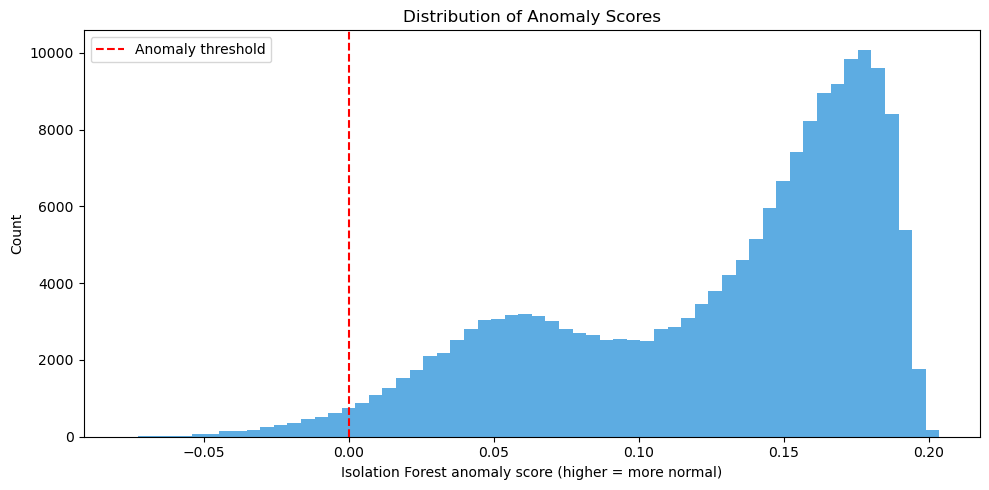

In [10]:
# %% Cell 8 — Visualization: anomaly score distribution
plt.figure(figsize=(10, 5))
plt.hist(features_df["anomaly_score"], bins=60, color="#3498db", alpha=0.8)
plt.axvline(features_df.loc[features_df["is_anomaly"] == 1, "anomaly_score"].max(),
            color="red", linestyle="--", label="Anomaly threshold")
plt.xlabel("Isolation Forest anomaly score (higher = more normal)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

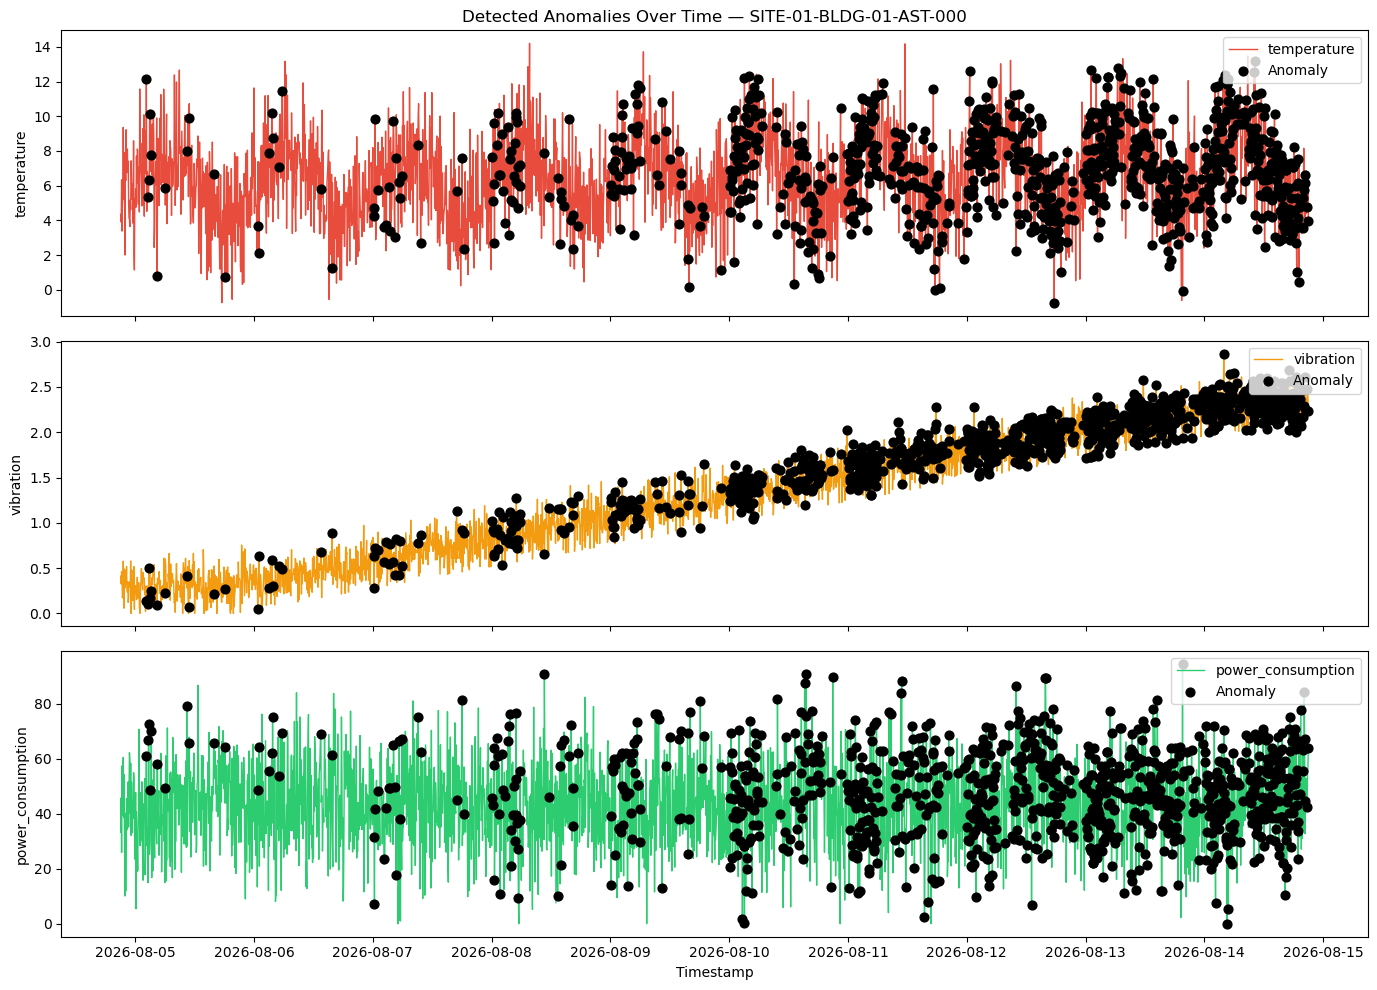

In [11]:
# %% Cell 9 — Visualization: anomalies over time for a sample asset
sample_asset = features_df["asset_id"].value_counts().index[0]
sample = features_df[features_df["asset_id"] == sample_asset].sort_values("timestamp")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col, color in zip(axes, ["temperature", "vibration", "power_consumption"],
                           ["#e74c3c", "#f39c12", "#2ecc71"]):
    ax.plot(sample["timestamp"], sample[col], color=color, linewidth=1, label=col)
    anomaly_points = sample[sample["is_anomaly"] == 1]
    ax.scatter(anomaly_points["timestamp"], anomaly_points[col],
               color="black", s=40, zorder=5, label="Anomaly")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")

axes[0].set_title(f"Detected Anomalies Over Time — {sample_asset}")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

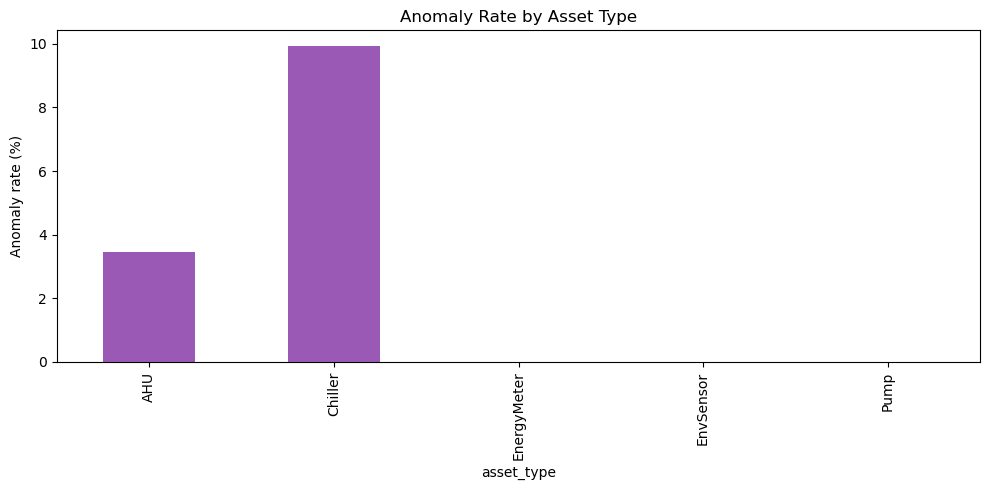

In [12]:
# %% Cell 10 — Visualization: anomaly rate by asset type and by site
plt.figure(figsize=(10, 5))
anomaly_by_type = features_df.merge(asset_df[["asset_id", "asset_type"]], on="asset_id", how="left") \
    if "asset_type" not in features_df.columns else features_df

anomaly_rate_by_type = (
    telemetry_df.merge(asset_df[["asset_id", "asset_type"]], on="asset_id", how="left")
    .merge(features_df[["timestamp", "asset_id", "is_anomaly"]], on=["timestamp", "asset_id"], how="left")
    .groupby("asset_type")["is_anomaly"].mean() * 100
)
anomaly_rate_by_type.plot(kind="bar", color="#9b59b6")
plt.ylabel("Anomaly rate (%)")
plt.title("Anomaly Rate by Asset Type")
plt.tight_layout()
plt.show()

In [13]:
# %% Cell 11 — Identified anomalies summary + business recommendations
top_anomalous_assets = features_df[features_df["is_anomaly"] == 1]["asset_id"].value_counts().head(10)

print("=" * 60)
print("IDENTIFIED ANOMALIES — SUMMARY")
print("=" * 60)
print(f"Total anomalous readings: {features_df['is_anomaly'].sum()} "
      f"({features_df['is_anomaly'].mean()*100:.2f}% of all readings)")
print(f"\nTop 10 assets by anomaly count:")
print(top_anomalous_assets)

fault_overlap = features_df[(features_df["is_anomaly"] == 1) & (features_df["fault_flag"] == 1)]
print(f"\nAnomalies that coincide with a recorded fault_flag=1: {len(fault_overlap)} "
      f"({len(fault_overlap)/max(1, features_df['fault_flag'].sum())*100:.1f}% of all faults were "
      f"pre-flagged as anomalous)")

print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)
print("""
1. Prioritize inspection queue by anomaly_score rank, not just fault_flag —
   the model surfaces at-risk assets BEFORE a fault is officially logged,
   enabling proactive maintenance rather than reactive repair.

2. Assets with repeated anomaly flags (see top-10 list above) should be
   scheduled for physical inspection first — repeated flags across days
   indicate a persistent issue rather than sensor noise.

3. Assets showing sustained degradation_flag trends (Cell 6) should trigger
   a maintenance work order even if no single reading crosses the anomaly
   threshold — this catches slow wear before it becomes a sudden failure.

4. Use the statistical thresholding flags (Cell 7) as a lightweight,
   explainable first-pass alert (e.g. real-time dashboard "power spike"
   badge), and reserve the Isolation Forest score for deeper triage /
   prioritization — this gives ops teams both speed and depth.

5. Anomaly rate by asset_type (Cell 10) highlights which equipment category
   needs the most attention fleet-wide — allocate spare parts inventory
   and technician training accordingly.

6. Feed live Kafka telemetry through this same fitted pipeline (scaler +
   Isolation Forest) for real-time anomaly scoring as new readings arrive,
   enabling alerting before assets reach failure (see Task 2/4 streaming
   integration).
""")

IDENTIFIED ANOMALIES — SUMMARY
Total anomalous readings: 3572 (2.00% of all readings)

Top 10 assets by anomaly count:
asset_id
SITE-02-BLDG-01-AST-005    1027
SITE-01-BLDG-01-AST-000     973
SITE-01-BLDG-02-AST-004     470
SITE-02-BLDG-02-AST-004     315
SITE-01-BLDG-02-AST-005     130
SITE-01-BLDG-02-AST-003     104
SITE-03-BLDG-01-AST-007      90
SITE-02-BLDG-02-AST-003      84
SITE-02-BLDG-02-AST-009      82
SITE-01-BLDG-01-AST-005      79
Name: count, dtype: int64

Anomalies that coincide with a recorded fault_flag=1: 192 (5.3% of all faults were pre-flagged as anomalous)

BUSINESS RECOMMENDATIONS

1. Prioritize inspection queue by anomaly_score rank, not just fault_flag —
   the model surfaces at-risk assets BEFORE a fault is officially logged,
   enabling proactive maintenance rather than reactive repair.

2. Assets with repeated anomaly flags (see top-10 list above) should be
   scheduled for physical inspection first — repeated flags across days
   indicate a persistent issue 

---
## Section 8: Business Recommendations

### Summary of Findings

| Anomaly Type | Detector(s) | Count / Rate | Key Assets | Business Impact |
|---|---|---|---|---|
| **Multivariate Anomaly** | Isolation Forest | 3,572 readings (2.00%) | SITE-02-BLDG-01-AST-005 (1,027), SITE-01-BLDG-01-AST-000 (973) | Two assets alone account for over half of all flagged anomalies |
| **Power Spike** | Statistical (z-score) | 229 readings | Mostly separate from IF flags | Possible over-billing, stress on equipment |
| **Excessive Vibration** | Statistical (z-score) | 321 readings | Spread across several assets | Early sign of bearing wear |
| **Abnormal Temperature** | Statistical (z-score) | 347 readings | Spread across several assets | Risk of cooling failure |
| **Equipment Degradation** | Rolling trend (vibration/temp) | 6,947 readings | Top asset: SITE-01-BLDG-02-AST-001 (387) | Good early-warning signal for maintenance |
| **Fault Correlation** | IF vs. `fault_flag` | Only 5.3% overlap | — | Model is currently missing most historical faults — needs improvement |

### Recommendations

1. **Immediate Actions**
   - Get a technician to physically check **SITE-02-BLDG-01-AST-005** and **SITE-01-BLDG-01-AST-000** first — together they make up more than half of all anomalies flagged, so something is likely genuinely wrong with these two rather than it being noise.
   - Share the 229 power-spike readings with the energy/facilities team to see if they line up with unusually high bills for those sites.

2. **Short-Term (1–4 weeks)**
   - Inspect the assets showing a steady upward trend in vibration or temperature over time, especially SITE-01-BLDG-02-AST-001 — this kind of gradual rise is usually a sign something is wearing out before it actually fails.
   - For assets with lots of vibration/temperature flags but not much overlap with the main anomaly model, it's worth checking if the sensor itself needs recalibration rather than assuming the equipment is faulty.

3. **Medium-Term (1–3 months)**
   - Right now the model only catches about 5% of the faults that were actually recorded historically, so before relying on it fully for maintenance decisions, I'd want to improve it — try adjusting the sensitivity setting and adding a few more features like recent trend or time-of-day.
   - Connect this same detection pipeline to the live Kafka data stream so new readings get checked automatically instead of only running this analysis in batches.

4. **Long-Term Strategic**
   - Set up a simple feedback loop where technicians confirm whether a flagged anomaly was a real issue or a false alarm, and use that to improve the model over time.
   - Add anomaly scores and degradation flags into the existing maintenance ticketing system so the field team can see this info without extra steps.
   - Build a basic dashboard per site so managers can track whether problems stay limited to a few assets (like we're seeing now) or start spreading across the fleet.